In [1]:
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd

# Same project layout as the previous notebooks.
project_root = Path.cwd().parent

notebook_dir = Path().resolve()

data_folder = project_root / "data" / "resources"
Pilot = data_folder / "PilotStudy_All"

# Get graph prevouly fitered
GRAPH_PATH = data_folder / "generated" / "modified_graph.gml"
# Get the original graph for matching ids
human1_xml = data_folder / "Human-GEM.xml"
graph = nx.read_gml(GRAPH_PATH)

if graph.is_directed() or graph.is_multigraph():
    raise ValueError("Use the simple, undirected reference graph.")

if nx.number_of_selfloops(graph) > 0:
    raise ValueError("The reference graph contains self-loops.")

if not nx.is_connected(graph):
    raise ValueError("This analysis requires the connected reference graph.")

graph_nodes = list(graph.nodes())
node_to_index = {
    node: index for index, node in enumerate(graph_nodes)
}
n = len(graph_nodes)

# Sampling settings.
K_VALUES = list(range(60, 201, 20))
N_RANDOM_PER_K = 2
BASE_SEED = 42

# Parameter settings for the later sensitivity analysis.
REFERENCE_D = 7.0
D_REF_VALUES = np.array([6.0, 6.5, 7.0, 7.5, 8.0])

rho = nx.density(graph)
mu = 1.0 - rho

# Optional: mapped graph-node IDs from an actual dataset.
# Leave as None to run entirely with generated configurations.
REFERENCE_NODE_IDS = None

if n < max(K_VALUES) + 3:
    raise ValueError(
        "The graph needs at least max(k) + 3 nodes "
        "to allow the planned three-node swaps."
    )

# Shortest-path distances on the full reference graph.
distance_matrix = np.full((n, n), np.inf, dtype=float)

for source, lengths in nx.all_pairs_shortest_path_length(graph):
    columns = np.fromiter(
        (node_to_index[node] for node in lengths),
        dtype=int,
    )
    distance_matrix[node_to_index[source], columns] = np.fromiter(
        lengths.values(), dtype=float
    )

print(f"Graph: {n} nodes, {graph.number_of_edges()} edges")
print(f"Density: {rho:.6f}")
print(f"k values: {K_VALUES}")
print(f"Distance matrix: {distance_matrix.shape}")

Graph: 3240 nodes, 7254 edges
Density: 0.001382
k values: [60, 80, 100, 120, 140, 160, 180, 200]
Distance matrix: (3240, 3240)


In [2]:
def closest_indices(distances, k, rng):
    """Select the k nearest nodes, breaking distance ties randomly."""
    permutation = rng.permutation(len(distances))
    order = np.argsort(
        distances[permutation],
        kind="stable",
    )
    return permutation[order[:k]]


def sample_clustered(k, rng):
    """Select a connected neighborhood around one random centre."""
    center = int(rng.integers(n))
    return closest_indices(distance_matrix[center], k, rng)


def sample_dispersed(k, rng):
    """Greedily maximize distance to the nearest selected node."""
    selected = [int(rng.integers(n))]

    # Copy so the reference distance matrix is never modified.
    nearest = distance_matrix[selected[0]].copy()
    nearest[selected[0]] = -np.inf

    while len(selected) < k:
        candidates = np.flatnonzero(nearest == nearest.max())
        next_node = int(rng.choice(candidates))
        selected.append(next_node)

        nearest = np.minimum(
            nearest,
            distance_matrix[next_node],
        )
        nearest[next_node] = -np.inf

    return np.asarray(selected, dtype=int)


def sample_neighborhoods(k, rng, n_centers=4):
    """Select nodes near several separated centres."""
    centers = sample_dispersed(min(n_centers, k), rng)
    nearest_center = distance_matrix[centers].min(axis=0)

    return closest_indices(nearest_center, k, rng)


def sample_random(k, rng):
    """Select k nodes uniformly without replacement."""
    return rng.choice(n, size=k, replace=False)

In [4]:
sample_bank = {}
sampling_rows = []

sampling_methods = [
    ("neighborhoods", sample_neighborhoods),
    ("clustered", sample_clustered),
    ("dispersed", sample_dispersed),
] + [
    ("random", sample_random)
    for _ in range(N_RANDOM_PER_K)
]

for k in K_VALUES:
    for sample_number, (kind, sampler) in enumerate(sampling_methods):
        seed = BASE_SEED + 1000 * k + sample_number
        rng = np.random.default_rng(seed)

        indices = np.sort(sampler(k, rng))

        if len(indices) != k or len(np.unique(indices)) != k:
            raise ValueError(
                f"Invalid configuration: {kind}, k={k}."
            )

        sample_id = f"{kind}_k{k}_{sample_number + 1:02d}"
        sample_bank[sample_id] = indices

        sampling_rows.append({
            "sample_id": sample_id,
            "kind": kind,
            "k": k,
            "seed": seed,
        })

# Optional exact copy of a mapped experimental configuration.
if REFERENCE_NODE_IDS is not None:
    reference_nodes = list(dict.fromkeys(REFERENCE_NODE_IDS))

    missing = set(reference_nodes) - set(graph_nodes)
    if missing:
        raise ValueError(
            f"{len(missing)} reference IDs are absent from the graph."
        )

    reference_k = len(reference_nodes)
    if not min(K_VALUES) <= reference_k <= max(K_VALUES):
        raise ValueError(
            "The reference configuration falls outside the chosen k range."
        )

    sample_id = f"reference_copy_k{reference_k}"
    sample_bank[sample_id] = np.sort([
        node_to_index[node] for node in reference_nodes
    ])

    sampling_rows.append({
        "sample_id": sample_id,
        "kind": "reference_copy",
        "k": reference_k,
        "seed": None,
    })

sampling_table = (
    pd.DataFrame(sampling_rows)
    .set_index("sample_id")
)

sampling_counts = (
    sampling_table.groupby(["k", "kind"])
    .size()
    .unstack(fill_value=0)
)

print(f"Total configurations: {len(sample_bank)}")
display(sampling_counts)

Total configurations: 40


kind,clustered,dispersed,neighborhoods,random
k,,,,
60,1,1,1,2
80,1,1,1,2
100,1,1,1,2
120,1,1,1,2
140,1,1,1,2
160,1,1,1,2
180,1,1,1,2
200,1,1,1,2


In [5]:
from etc.hamiltonian import Hamiltonian

# Create the model once and reuse it in subsequent cells.
H = Hamiltonian(graph)

gamma_reference = rho * REFERENCE_D**2

evaluation_rows = []

for sample_id, indices in sample_bank.items():
    h_value, attractive, distance_dependent = H.compute(
        indices,
        mu=mu,
        gamma=gamma_reference,
    )

    # The library returns signed, weighted contributions.
    if not np.isclose(h_value, attractive + distance_dependent):
        raise ValueError(
            f"Inconsistent contributions for {sample_id}."
        )

    evaluation_rows.append({
        "sample_id": sample_id,
        "attractive_contribution": float(attractive),
        "distance_contribution": float(distance_dependent),
        "H": float(h_value),
        "E": float(abs(h_value)),
    })

baseline_values = (
    pd.DataFrame(evaluation_rows)
    .set_index("sample_id")
)

# Retain the sampling metadata alongside the calculated values.
baseline_results = sampling_table.join(
    baseline_values,
    validate="one_to_one",
)

baseline_results["d_ref"] = REFERENCE_D
baseline_results["mu"] = mu
baseline_results["gamma"] = gamma_reference

print(
    f"Reference parameters: "
    f"d_ref={REFERENCE_D:.2f}, "
    f"mu={mu:.6f}, "
    f"gamma={gamma_reference:.6f}"
)

display(
    baseline_results[
        [
            "kind",
            "k",
            "attractive_contribution",
            "distance_contribution",
            "H",
            "E",
        ]
    ]
    .sort_values(["k", "kind"])
    .round(6)
)

Reference parameters: d_ref=7.00, mu=0.998618, gamma=0.067740


,kind,k,attractive_contribution,distance_contribution,H,E
sample_id,,,,,,
clustered_k60_02,clustered,60,-125.825810,21.659989,-104.165822,104.165822
dispersed_k60_03,dispersed,60,-0.000000,0.561869,0.561869,0.561869
neighborhoods_k60_01,neighborhoods,60,-74.896316,18.187586,-56.708730,56.708730
random_k60_04,random,60,-2.995853,3.598394,0.602541,0.602541
random_k60_05,random,60,-0.000000,3.255164,3.255164,3.255164
clustered_k80_02,clustered,80,-150.791249,37.696942,-113.094307,113.094307
dispersed_k80_03,dispersed,80,-0.000000,1.197179,1.197179,1.197179
neighborhoods_k80_01,neighborhoods,80,-121.831340,24.612790,-97.218551,97.218551
random_k80_04,random,80,-1.997235,5.411999,3.414764,3.414764


In [6]:
from etc.optimization import EnergyOptimizer

optimizer = EnergyOptimizer(H)

N_RESTARTS = 3
ANNEALING_STEPS = 10_000


def search_emax(k, d_ref):
    """Estimate maximum absolute energy from several starting configurations."""
    gamma_value = rho * float(d_ref)**2
    records = []

    starting_methods = [
        ("clustered", sample_clustered),
        ("dispersed", sample_dispersed),
    ]

    for repeat in range(N_RESTARTS):
        for method_number, (kind, sampler) in enumerate(starting_methods):

            # Reuse the same seeds when comparing different d_ref values.
            seed = (
                BASE_SEED
                + 1_000_000
                + 1000 * k
                + 10 * repeat
                + method_number
            )
            rng = np.random.default_rng(seed)

            initial_indices = sampler(k, rng)
            initial_mask = np.zeros(n, dtype=int)
            initial_mask[initial_indices] = 1

            initial_energy = abs(
                H.compute(
                    initial_indices,
                    mu=mu,
                    gamma=gamma_value,
                )[0]
            )

            best_mask, reported_energy, _ = (
                optimizer.max_energy_annealing(
                    S0_config=initial_mask.copy(),
                    mu=mu,
                    gamma=gamma_value,
                    steps=ANNEALING_STEPS,
                    n_workers=1,
                    Tmin=1e-60,
                    seed=seed,
                )
            )

            # Verify the returned configuration and recompute its energy.
            best_mask = np.asarray(best_mask)

            if (
                best_mask.shape != (n,)
                or not np.isin(best_mask, [0, 1]).all()
                or best_mask.sum() != k
            ):
                raise ValueError("The optimizer returned an invalid mask.")

            best_indices = np.flatnonzero(best_mask)

            optimized_energy = abs(
                H.compute(
                    best_indices,
                    mu=mu,
                    gamma=gamma_value,
                )[0]
            )

            if not np.isclose(reported_energy, optimized_energy):
                raise ValueError(
                    "Reported and recomputed energies do not agree."
                )

            records.append({
                "k": k,
                "d_ref": float(d_ref),
                "gamma": gamma_value,
                "initialization": kind,
                "repeat": repeat + 1,
                "seed": seed,
                "E_initial": float(initial_energy),
                "E_optimized": float(optimized_energy),
                "Emax_run": float(
                    max(initial_energy, optimized_energy)
                ),
            })

    return records


# Search once per observation count, shared by all samples with that k.
emax_records = []

for k in sorted(sampling_table["k"].unique()):
    k_records = search_emax(int(k), REFERENCE_D)
    emax_records.extend(k_records)

    largest_energy = max(row["Emax_run"] for row in k_records)
    print(f"k={k}: largest energy found = {largest_energy:.6f}")

emax_runs = pd.DataFrame(emax_records)

emax_table = (
    emax_runs.groupby("k")
    .agg(
        Emax_search=("Emax_run", "max"),
        lowest_run_estimate=("Emax_run", "min"),
        n_searches=("Emax_run", "size"),
    )
)

# Existing sampled configurations are also valid candidates.
emax_table["Emax_known_samples"] = (
    baseline_results.groupby("k")["E"].max()
)

emax_table["Emax"] = emax_table[
    ["Emax_search", "Emax_known_samples"]
].max(axis=1)

emax_table["known_sample_exceeds_search"] = (
    emax_table["Emax_known_samples"]
    > emax_table["Emax_search"] + 1e-8
)

if (
    not np.isfinite(emax_table["Emax"]).all()
    or (emax_table["Emax"] <= 0).any()
):
    raise ValueError("Normalization requires a finite, positive Emax.")

# Apply the same estimated bound to all configurations of equal size.
baseline_coverage = baseline_results.join(
    emax_table[["Emax"]],
    on="k",
    validate="many_to_one",
)

baseline_coverage["Emin_assumed"] = 0.0
baseline_coverage["C"] = (
    1.0 - baseline_coverage["E"] / baseline_coverage["Emax"]
)

display(emax_table.round(6))

display(
    baseline_coverage[
        ["kind", "k", "H", "E", "Emax", "C"]
    ]
    .sort_values(["k", "kind"])
    .round(6)
)

k=60: largest energy found = 438.684988
k=80: largest energy found = 622.417530
k=100: largest energy found = 779.247657
k=120: largest energy found = 973.395975
k=140: largest energy found = 1131.095556
k=160: largest energy found = 1202.670870
k=180: largest energy found = 1198.559505
k=200: largest energy found = 1089.474678


,Emax_search,lowest_run_estimate,n_searches,Emax_known_samples,Emax,known_sample_exceeds_search
k,,,,,,
60,438.684988,23.374197,6,104.165822,438.684988,False
80,622.417530,36.850337,6,113.094307,622.417530,False
100,779.247657,50.535382,6,132.288141,779.247657,False
120,973.395975,64.291874,6,142.486597,973.395975,False
140,1131.095556,87.774192,6,143.388997,1131.095556,False
160,1202.670870,109.914328,6,700.848836,1202.670870,False
180,1198.559505,130.060638,6,474.312658,1198.559505,False
200,1089.474678,143.230555,6,687.360109,1089.474678,False


,kind,k,H,E,Emax,C
sample_id,,,,,,
clustered_k60_02,clustered,60,-104.165822,104.165822,438.684988,0.762550
dispersed_k60_03,dispersed,60,0.561869,0.561869,438.684988,0.998719
neighborhoods_k60_01,neighborhoods,60,-56.708730,56.708730,438.684988,0.870730
random_k60_04,random,60,0.602541,0.602541,438.684988,0.998626
random_k60_05,random,60,3.255164,3.255164,438.684988,0.992580
clustered_k80_02,clustered,80,-113.094307,113.094307,622.417530,0.818298
dispersed_k80_03,dispersed,80,1.197179,1.197179,622.417530,0.998077
neighborhoods_k80_01,neighborhoods,80,-97.218551,97.218551,622.417530,0.843805
random_k80_04,random,80,3.414764,3.414764,622.417530,0.994514


In [7]:
sensitivity_frames = []
sensitivity_searches = []
sensitivity_bounds = []

for d_ref in D_REF_VALUES:
    d_ref = float(d_ref)
    gamma_value = rho * d_ref**2
    gamma_ratio = (d_ref / REFERENCE_D)**2

    # Evaluate the same configurations under the new parameter setting.
    current = baseline_results.copy()

    current["d_ref"] = d_ref
    current["gamma"] = gamma_value
    current["gamma_ratio"] = gamma_ratio

    current["distance_contribution"] = (
        baseline_results["distance_contribution"] * gamma_ratio
    )

    current["H"] = (
        current["attractive_contribution"]
        + current["distance_contribution"]
    )
    current["E"] = current["H"].abs()

    # Reuse the completed searches at the reference setting.
    if np.isclose(d_ref, REFERENCE_D):
        runs = emax_runs.copy()

    else:
        run_records = []

        for k in sorted(sampling_table["k"].unique()):
            print(
                f"d_ref={d_ref:.1f}: estimating Emax for k={k}",
                flush=True,
            )

            run_records.extend(
                search_emax(int(k), d_ref)
            )

        runs = pd.DataFrame(run_records)

    sensitivity_searches.append(runs)

    # One normalization estimate per k at this parameter setting.
    bounds = (
        runs.groupby("k")
        .agg(
            Emax_search=("Emax_run", "max"),
            lowest_run_estimate=("Emax_run", "min"),
            n_searches=("Emax_run", "size"),
        )
    )

    bounds["Emax_known_samples"] = (
        current.groupby("k")["E"].max()
    )

    bounds["Emax"] = bounds[
        ["Emax_search", "Emax_known_samples"]
    ].max(axis=1)

    bounds["known_sample_exceeds_search"] = (
        bounds["Emax_known_samples"]
        > bounds["Emax_search"] + 1e-8
    )

    if (
        not np.isfinite(bounds["Emax"]).all()
        or (bounds["Emax"] <= 0).any()
    ):
        raise ValueError(
            f"Invalid normalization bound at d_ref={d_ref}."
        )

    sensitivity_bounds.append(
        bounds.assign(
            d_ref=d_ref,
            gamma=gamma_value,
        ).reset_index()
    )

    current = current.join(
        bounds[["Emax"]],
        on="k",
        validate="many_to_one",
    )

    # Retain the assumption Emin = 0.
    current["Emin_assumed"] = 0.0
    current["C"] = 1.0 - current["E"] / current["Emax"]

    # Changes relative to the same configuration at d_ref = 7.
    current["delta_H"] = (
        current["H"] - baseline_results["H"]
    )
    current["delta_C"] = (
        current["C"] - baseline_coverage["C"]
    )
    current["abs_delta_C"] = current["delta_C"].abs()

    sensitivity_frames.append(current)


parameter_results = (
    pd.concat(sensitivity_frames)
    .rename_axis("sample_id")
    .reset_index()
)

parameter_emax_runs = pd.concat(
    sensitivity_searches,
    ignore_index=True,
)

parameter_bounds = pd.concat(
    sensitivity_bounds,
    ignore_index=True,
)

# Compact summary across the sampled configurations.
parameter_summary = (
    parameter_results.groupby("d_ref")
    .agg(
        gamma=("gamma", "first"),
        gamma_ratio=("gamma_ratio", "first"),
        min_delta_C=("delta_C", "min"),
        max_delta_C=("delta_C", "max"),
        median_abs_delta_C=("abs_delta_C", "median"),
        max_abs_delta_C=("abs_delta_C", "max"),
    )
)

display(parameter_summary.round(6))

d_ref=6.0: estimating Emax for k=60
d_ref=6.0: estimating Emax for k=80
d_ref=6.0: estimating Emax for k=100
d_ref=6.0: estimating Emax for k=120
d_ref=6.0: estimating Emax for k=140
d_ref=6.0: estimating Emax for k=160
d_ref=6.0: estimating Emax for k=180
d_ref=6.0: estimating Emax for k=200
d_ref=6.5: estimating Emax for k=60
d_ref=6.5: estimating Emax for k=80
d_ref=6.5: estimating Emax for k=100
d_ref=6.5: estimating Emax for k=120
d_ref=6.5: estimating Emax for k=140
d_ref=6.5: estimating Emax for k=160
d_ref=6.5: estimating Emax for k=180
d_ref=6.5: estimating Emax for k=200
d_ref=7.5: estimating Emax for k=60
d_ref=7.5: estimating Emax for k=80
d_ref=7.5: estimating Emax for k=100
d_ref=7.5: estimating Emax for k=120
d_ref=7.5: estimating Emax for k=140
d_ref=7.5: estimating Emax for k=160
d_ref=7.5: estimating Emax for k=180
d_ref=7.5: estimating Emax for k=200
d_ref=8.0: estimating Emax for k=60
d_ref=8.0: estimating Emax for k=80
d_ref=8.0: estimating Emax for k=100
d_ref=8.0

,gamma,gamma_ratio,min_delta_C,max_delta_C,median_abs_delta_C,max_abs_delta_C
d_ref,,,,,,
6.0,0.049768,0.734694,-0.045475,0.085328,0.005045,0.085328
6.5,0.058409,0.862245,-0.066567,0.054569,0.002367,0.066567
7.0,0.067740,1.000000,0.000000,0.000000,0.000000,0.000000
7.5,0.077763,1.147959,-0.027270,0.091421,0.002997,0.091421
8.0,0.088477,1.306122,-0.024336,0.094614,0.006442,0.094614


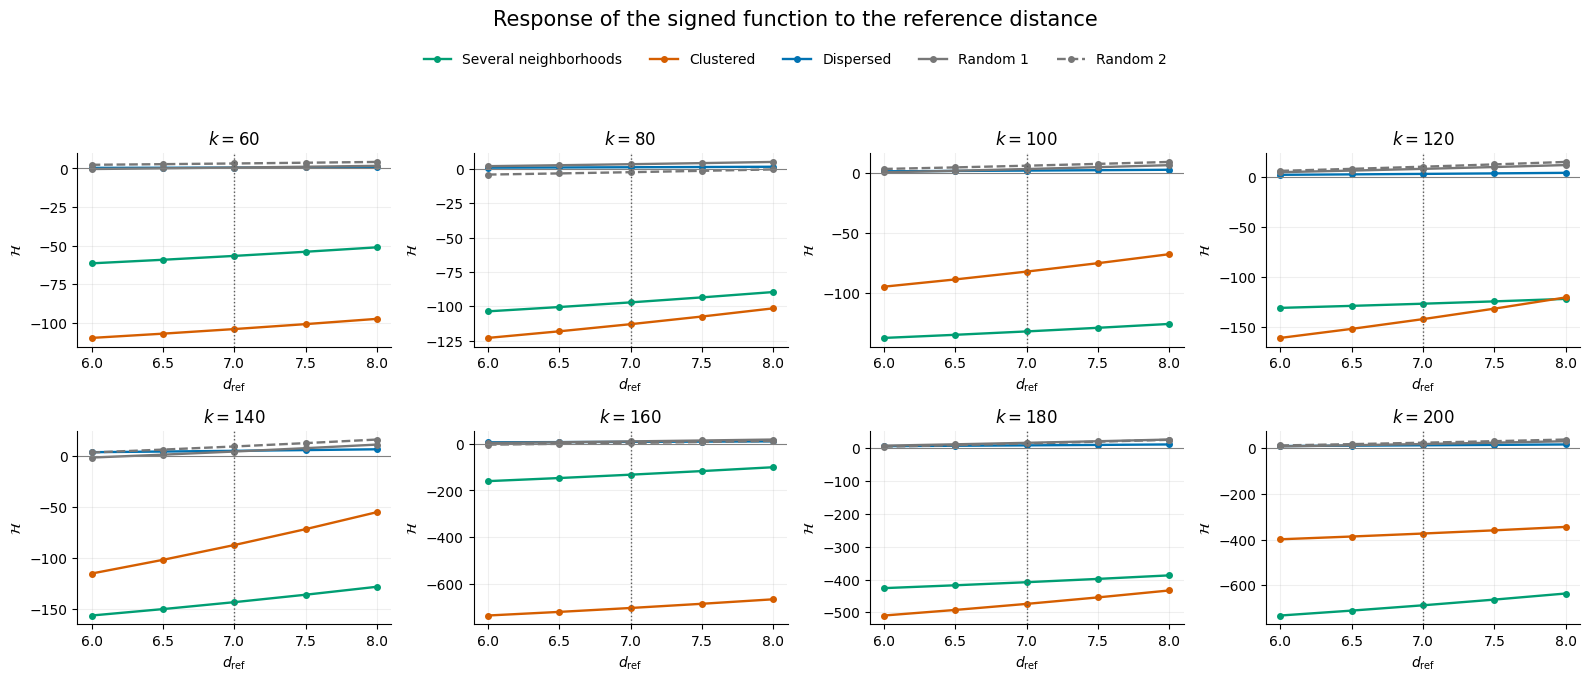

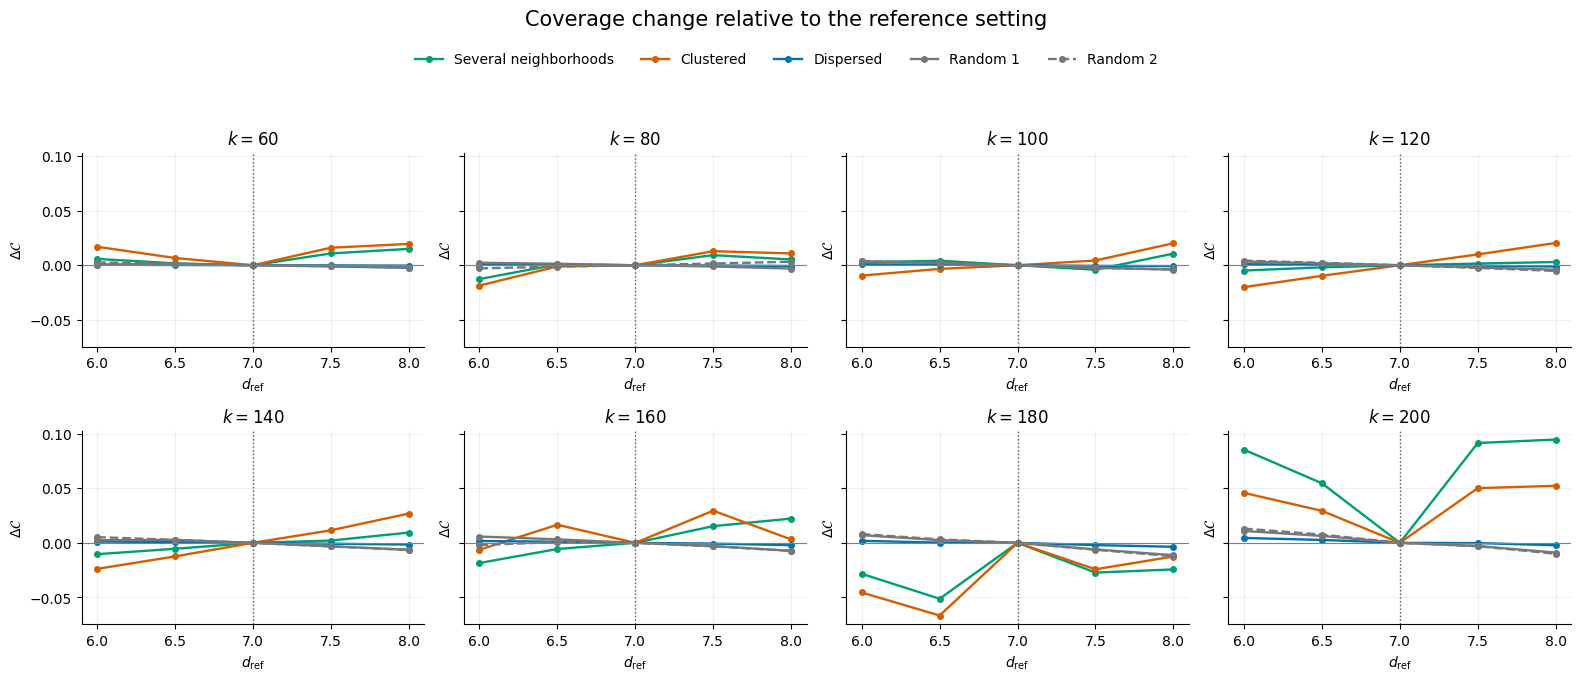

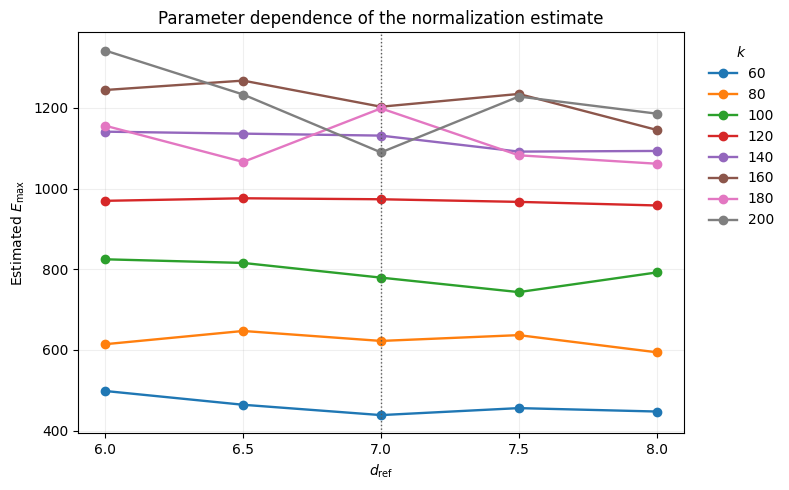

In [18]:
import matplotlib.pyplot as plt

FIGURE_DIR = project_root / "results" / "robustness"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

KIND_COLORS = {
    "neighborhoods": "#009E73",
    "clustered": "#D55E00",
    "dispersed": "#0072B2",
    "random": "#777777",
    "reference_copy": "#CC79A7",
}

KIND_LABELS = {
    "neighborhoods": "Several neighborhoods",
    "clustered": "Clustered",
    "dispersed": "Dispersed",
    "random": "Random",
    "reference_copy": "Reference copy",
}


def plot_sensitivity_by_k(
    column, ylabel, title, filename, share_y=False
):
    k_values = sorted(parameter_results["k"].unique())
    ncols = min(4, len(k_values))
    nrows = (len(k_values) + ncols - 1) // ncols

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 3.4 * nrows),
        sharex=True,
        sharey=share_y,
        squeeze=False,
    )

    legend_handles = {}
    line_styles = ["-", "--", ":", "-."]

    for ax, k in zip(axes.flat, k_values):
        panel = parameter_results[
            parameter_results["k"] == k
        ]

        for kind, color in KIND_COLORS.items():
            subset = panel[panel["kind"] == kind]

            for number, (sample_id, curve) in enumerate(
                subset.groupby("sample_id", sort=True)
            ):
                curve = curve.sort_values("d_ref")

                label = KIND_LABELS[kind]
                if kind == "random":
                    label += f" {number + 1}"

                line, = ax.plot(
                    curve["d_ref"],
                    curve[column],
                    color=color,
                    linestyle=line_styles[number % len(line_styles)],
                    marker="o",
                    markersize=4,
                    linewidth=1.7,
                )

                legend_handles.setdefault(label, line)

        ax.axhline(0, color="0.5", linewidth=0.8)
        ax.axvline(
            REFERENCE_D,
            color="0.35",
            linestyle=":",
            linewidth=1,
        )

        ax.set_title(f"$k={k}$")
        ax.set_xlabel(r"$d_{\mathrm{ref}}$")
        ax.set_ylabel(ylabel)
        ax.set_xticks(D_REF_VALUES)
        ax.tick_params(labelbottom=True)
        ax.grid(alpha=0.2)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    for ax in list(axes.flat)[len(k_values):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=15, y=0.995)

    fig.legend(
        handles=list(legend_handles.values()),
        labels=list(legend_handles),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=min(6, len(legend_handles)),
        frameon=False,
    )

    fig.tight_layout(rect=(0, 0, 1, 0.89))
    fig.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


# 1. Signed H: independent vertical scales for each k.
plot_sensitivity_by_k(
    column="H",
    ylabel=r"$\mathcal{H}$",
    title="Response of the signed function to the reference distance",
    filename="parameter_sensitivity_H.png",
    share_y=False,
)

# 2. Coverage changes: a common vertical scale across all k.
plot_sensitivity_by_k(
    column="delta_C",
    ylabel=r"$\Delta\mathcal{C}$",
    title="Coverage change relative to the reference setting",
    filename="parameter_sensitivity_delta_C.png",
    share_y=True,
)

# 3. Estimated maximum energy used for normalization.
fig, ax = plt.subplots(figsize=(8, 5))

for k, curve in parameter_bounds.groupby("k", sort=True):
    curve = curve.sort_values("d_ref")

    ax.plot(
        curve["d_ref"],
        curve["Emax"],
        marker="o",
        linewidth=1.7,
        label=f"{k}",
    )

ax.axvline(
    REFERENCE_D,
    color="0.35",
    linestyle=":",
    linewidth=1,
)

ax.set_xlabel(r"$d_{\mathrm{ref}}$")
ax.set_ylabel(r"Estimated $E_{\max}$")
ax.set_title("Parameter dependence of the normalization estimate")
ax.set_xticks(D_REF_VALUES)
ax.grid(alpha=0.2)

ax.legend(
    title="$k$",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "parameter_sensitivity_Emax.png",
    dpi=300,
    bbox_inches="tight",
)
#plt.savefig(data_folder/f'figs/parameter_sensitivity{k}.png')
plt.show()

In [14]:
def plot_sensitivity_by_k(
    column, ylabel, title, filename,
    share_y=False, k_max=None
):
    k_values = sorted(parameter_results["k"].unique())

    if k_max is not None:
        k_values = [k for k in k_values if k <= k_max]

    if not k_values:
        raise ValueError("No observation counts match the selected range.")

    # Three columns give six panels for k = 60, ..., 160.
    ncols = min(3 if k_max is not None else 4, len(k_values))
    nrows = (len(k_values) + ncols - 1) // ncols

    # Keep the rest of your function unchanged.

In [11]:
N_SWAP_TRIALS = 200
SWAP_COUNTS = (1, 2, 3)

swap_gamma = rho * REFERENCE_D**2

# Ensure that the reference scores use the intended parameters.
if (
    not np.allclose(baseline_coverage["mu"], mu)
    or not np.allclose(baseline_coverage["gamma"], swap_gamma)
):
    raise ValueError(
        "The baseline scores do not match the swap-analysis parameters."
    )

all_indices = np.arange(n)
node_degrees = np.array([
    graph.degree(node) for node in graph_nodes
])

swap_records = []

for sample_number, sample_id in enumerate(sorted(sample_bank)):
    original = np.asarray(sample_bank[sample_id], dtype=int)
    reference = baseline_coverage.loc[sample_id]

    k = len(original)
    outside = np.setdiff1d(all_indices, original)

    swap_seed = BASE_SEED + 2_000_000 + sample_number
    rng = np.random.default_rng(swap_seed)

    reference_emax = float(reference["Emax"])

    for trial in range(N_SWAP_TRIALS):
        removed = rng.choice(
            original, size=max(SWAP_COUNTS), replace=False
        )
        added = rng.choice(
            outside, size=max(SWAP_COUNTS), replace=False
        )

        for q in SWAP_COUNTS:
            remaining = original[
                ~np.isin(original, removed[:q])
            ]

            perturbed = np.sort(
                np.concatenate([remaining, added[:q]])
            )

            h_value, attractive, distance_dependent = H.compute(
                perturbed,
                mu=mu,
                gamma=swap_gamma,
            )

            energy = float(abs(h_value))
            coverage = 1.0 - energy / reference_emax

            swap_records.append({
                "sample_id": sample_id,
                "kind": reference["kind"],
                "k": k,
                "trial": trial + 1,
                "seed": swap_seed,
                "swaps": q,
                "percent_replaced": 100.0 * q / k,
                "H": float(h_value),
                "E": energy,
                "C": coverage,
                "Emax": reference_emax,
                "delta_H": float(h_value - reference["H"]),
                "delta_E": float(energy - reference["E"]),
                "delta_C": float(coverage - reference["C"]),
                "delta_attraction": float(
                    attractive - reference["attractive_contribution"]
                ),
                "delta_distance": float(
                    distance_dependent
                    - reference["distance_contribution"]
                ),
                "removed_nodes": tuple(
                    graph_nodes[int(i)] for i in removed[:q]
                ),
                "added_nodes": tuple(
                    graph_nodes[int(i)] for i in added[:q]
                ),
                "removed_degrees": tuple(
                    int(node_degrees[i]) for i in removed[:q]
                ),
                "added_degrees": tuple(
                    int(node_degrees[i]) for i in added[:q]
                ),
                "outside_bounds": bool(
                    coverage < -1e-10 or coverage > 1.0 + 1e-10
                ),
            })

    if (
        (sample_number + 1) % 5 == 0
        or sample_number + 1 == len(sample_bank)
    ):
        print(
            f"Completed {sample_number + 1}/{len(sample_bank)} "
            "configurations",
            flush=True,
        )

swap_results = pd.DataFrame(swap_records)

swap_results["abs_delta_H"] = swap_results["delta_H"].abs()
swap_results["abs_delta_C"] = swap_results["delta_C"].abs()

print(f"Evaluated perturbations: {len(swap_results):,}")
print(
    "Perturbations outside the estimated normalization bounds:",
    int(swap_results["outside_bounds"].sum()),
)

Completed 5/40 configurations
Completed 10/40 configurations
Completed 15/40 configurations
Completed 20/40 configurations
Completed 25/40 configurations
Completed 30/40 configurations
Completed 35/40 configurations
Completed 40/40 configurations
Evaluated perturbations: 24,000
Perturbations outside the estimated normalization bounds: 0


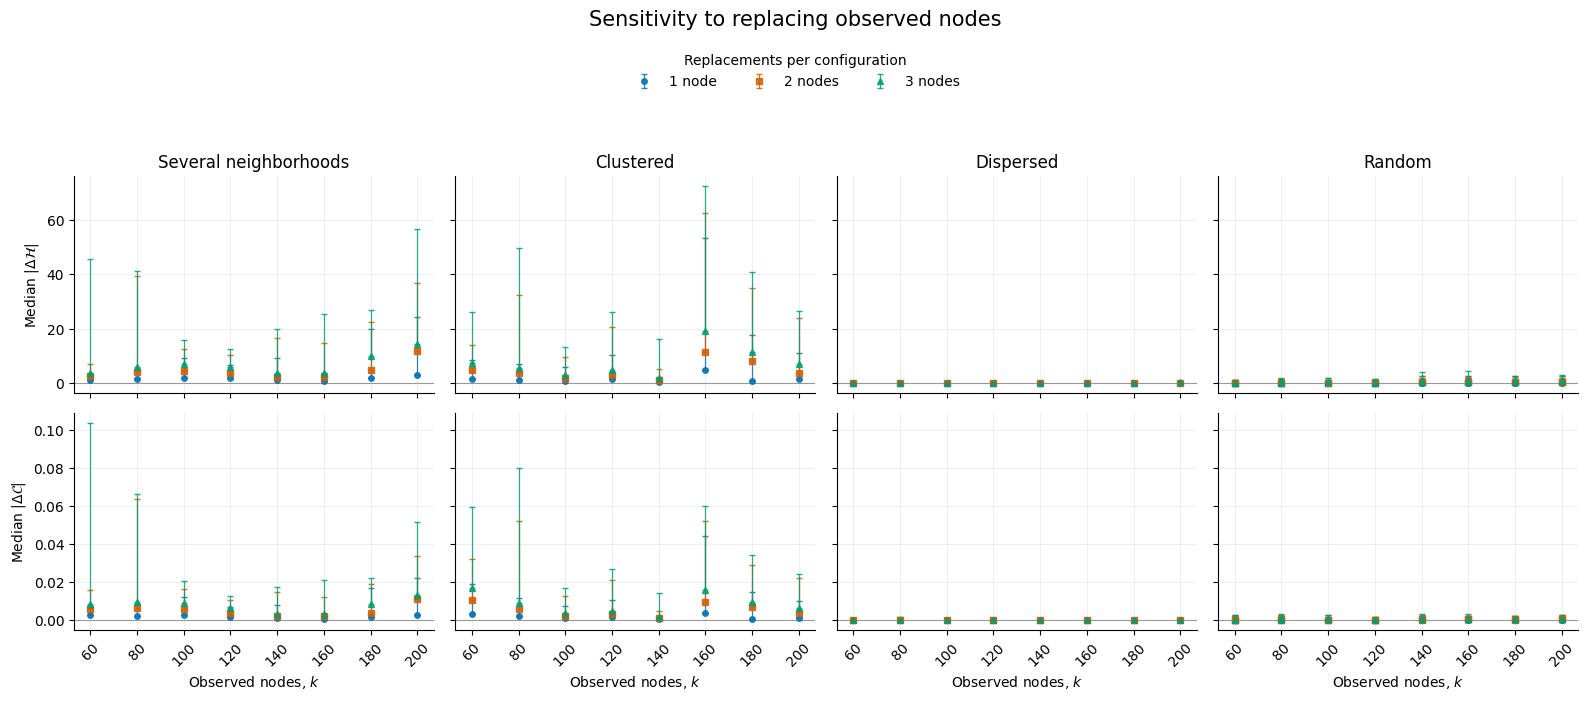

,sample_id,swaps,percent_replaced,delta_H,delta_C,delta_attraction,delta_distance,removed_nodes,added_nodes,removed_degrees,added_degrees,outside_bounds
13502,neighborhoods_k60_01,3,5.000000,48.349588,0.110215,48.932260,-0.582671,"(MAM02282l, MAM02527c, MAM03361m)","(MAM00452c, MAM00892m, MAM01271c)","(3, 51, 2)","(10, 2, 59)",False
13712,neighborhoods_k60_01,3,5.000000,47.732191,0.108807,48.932260,-1.200069,"(MAM02527c, MAM02250l, MAM02251l)","(MAM01017m, MAM02890c, MAM03932r)","(51, 4, 3)","(2, 5, 3)",False
13349,neighborhoods_k60_01,3,5.000000,47.415012,0.108084,47.933642,-0.518630,"(MAM02527c, MAM00622c, MAM02275l)","(MAM00983c, MAM00400c, MAM03637c)","(51, 1, 3)","(2, 2, 2)",False
13729,neighborhoods_k60_01,2,3.333333,47.312436,0.107851,47.933642,-0.621206,"(MAM02527c, MAM02250l)","(MAM02185e, MAM03203m)","(51, 4)","(1, 2)",False
13711,neighborhoods_k60_01,2,3.333333,47.270817,0.107756,47.933642,-0.662826,"(MAM02527c, MAM02250l)","(MAM01017m, MAM02890c)","(51, 4)","(2, 5)",False
4114,clustered_k60_02,2,3.333333,47.186737,0.107564,47.933642,-0.746905,"(MAM01947c, MAM01592c)","(MAM00107c, MAM02969c)","(7, 42)","(1, 8)",False
13348,neighborhoods_k60_01,2,3.333333,47.039801,0.107229,46.935025,0.104776,"(MAM02527c, MAM00622c)","(MAM00983c, MAM00400c)","(51, 1)","(2, 2)",False
13490,neighborhoods_k60_01,3,5.000000,46.737921,0.106541,47.933642,-1.195721,"(MAM02527c, MAM02244l, MAM02302l)","(MAM03131c, MAM02600c, MAM01856g)","(51, 3, 3)","(2, 3, 3)",False
4178,clustered_k60_02,3,5.000000,46.687814,0.106427,47.933642,-1.245828,"(MAM01592c, MAM02019c, MAM03110c)","(MAM01889c, MAM03956c, MAM03654c)","(42, 2, 24)","(3, 3, 2)",False
13778,neighborhoods_k60_01,3,5.000000,46.660859,0.106365,47.933642,-1.272783,"(MAM02527c, MAM02285l, MAM02243l)","(MAM01383c, MAM03103c, MAM01170c)","(51, 3, 4)","(5, 6, 3)",False


In [12]:
swap_summary = (
    swap_results
    .groupby(
        ["sample_id", "kind", "k", "swaps"],
        as_index=False,
    )
    .agg(
        n_trials=("trial", "nunique"),
        percent_replaced=("percent_replaced", "first"),
        median_abs_delta_H=("abs_delta_H", "median"),
        p95_abs_delta_H=(
            "abs_delta_H",
            lambda values: values.quantile(0.95),
        ),
        max_abs_delta_H=("abs_delta_H", "max"),
        median_delta_C=("delta_C", "median"),
        median_abs_delta_C=("abs_delta_C", "median"),
        p95_abs_delta_C=(
            "abs_delta_C",
            lambda values: values.quantile(0.95),
        ),
        max_abs_delta_C=("abs_delta_C", "max"),
        outside_bounds_count=("outside_bounds", "sum"),
    )
)

kinds = [
    kind for kind in KIND_LABELS
    if kind in swap_summary["kind"].unique()
]

swap_styles = {
    1: ("#0072B2", "o"),
    2: ("#D55E00", "s"),
    3: ("#009E73", "^"),
}

metrics = [
    (
        "median_abs_delta_H",
        "p95_abs_delta_H",
        r"Median $|\Delta\mathcal{H}|$",
    ),
    (
        "median_abs_delta_C",
        "p95_abs_delta_C",
        r"Median $|\Delta\mathcal{C}|$",
    ),
]

fig, axes = plt.subplots(
    2,
    len(kinds),
    figsize=(4 * len(kinds), 7),
    sharex=True,
    sharey="row",
    squeeze=False,
)

for column, kind in enumerate(kinds):
    for row, (median_column, p95_column, ylabel) in enumerate(metrics):
        ax = axes[row, column]

        for q, (color, marker) in swap_styles.items():
            subset = swap_summary[
                (swap_summary["kind"] == kind)
                & (swap_summary["swaps"] == q)
            ].sort_values(["k", "sample_id"])

            medians = subset[median_column].to_numpy()

            upper_whiskers = np.maximum(
                0,
                subset[p95_column].to_numpy() - medians,
            )

            ax.errorbar(
                subset["k"],
                medians,
                yerr=np.vstack([
                    np.zeros(len(subset)),
                    upper_whiskers,
                ]),
                fmt=marker,
                linestyle="none",
                color=color,
                markersize=4,
                capsize=2,
                elinewidth=0.9,
                alpha=0.85,
                label=f"{q} node" + ("s" if q > 1 else ""),
            )

        ax.axhline(0, color="0.6", linewidth=0.8)
        ax.grid(alpha=0.2)
        ax.set_xticks(sorted(sampling_table["k"].unique()))
        ax.tick_params(axis="x", labelrotation=45)

        if row == 0:
            ax.set_title(KIND_LABELS[kind])
        else:
            ax.set_xlabel(r"Observed nodes, $k$")

        if column == 0:
            ax.set_ylabel(ylabel)

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.suptitle(
    "Sensitivity to replacing observed nodes",
    fontsize=15,
    y=0.995,
)

fig.legend(
    handles,
    labels,
    title="Replacements per configuration",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=3,
    frameon=False,
)

fig.tight_layout(rect=(0, 0, 1, 0.86))

for extension in ["png", "pdf"]:
    fig.savefig(
        FIGURE_DIR / f"configuration_swap_sensitivity.{extension}",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()

# Retain the individual perturbations with the largest score changes.
largest_swap_changes = (
    swap_results.nlargest(10, "abs_delta_C")[
        [
            "sample_id",
            "swaps",
            "percent_replaced",
            "delta_H",
            "delta_C",
            "delta_attraction",
            "delta_distance",
            "removed_nodes",
            "added_nodes",
            "removed_degrees",
            "added_degrees",
            "outside_bounds",
        ]
    ]
)

display(largest_swap_changes)

In [13]:
import json

tables_to_save = {
    "sampling_configurations.csv": sampling_table.reset_index(),
    "baseline_coverage.csv": baseline_coverage.reset_index(),
    "parameter_sensitivity.csv": parameter_results,
    "parameter_sensitivity_summary.csv": (
        parameter_summary.reset_index()
    ),
    "parameter_energy_bounds.csv": parameter_bounds,
    "parameter_optimization_runs.csv": parameter_emax_runs,
    "configuration_swaps.csv": swap_results,
    "configuration_swaps_summary.csv": swap_summary,
    "largest_swap_changes.csv": largest_swap_changes,
}

for filename, table in tables_to_save.items():
    table.to_csv(FIGURE_DIR / filename, index=False)

# Save the actual selected node IDs for reproducibility.
sample_node_ids = {
    sample_id: [
        str(graph_nodes[int(i)]) for i in indices
    ]
    for sample_id, indices in sample_bank.items()
}

with open(
    FIGURE_DIR / "sampled_node_sets.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(sample_node_ids, handle, indent=2)

print("Results saved to:", FIGURE_DIR.resolve())

Results saved to: /home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/results/robustness
